# HNW & SWE Validation — HS2SWE (default parameters)

Validates the **HS2SWE** model against the **Mag25** dataset using default parameters.

**Model**: `HS2SWE` from `HS2SWE/model/HS2SWE.py`, run with all factory defaults.

**Workflow**
1. Load the multi-station NetCDF (`Mag25_all.nc`).
2. Build a 2D HS array (time × stations, in cm) and run `HS2SWE(...)` → `SWE_mod`.
3. Derive `HNW_mod` from day-to-day `SWE_mod` increments (negative melt diffs clipped to 0).
4. Validate **HNW** and **SWE** against observations, restricted to days with valid observed values.

In [19]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)

# ── Paths ─────────────────────────────────────────────────────────────────────
Mag25_nc_file = base_dir / "calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"
save_dir      = base_dir / "HNW_validation/results_HS2SWE"

# ── Imports ───────────────────────────────────────────────────────────────────
import HNW_validation.HNW_validation_helper as val_helper
sys.path.insert(0, str(base_dir / "HS2SWE/model"))
from HS2SWE import HS2SWE
from plot_style import apply_style, C
warnings.filterwarnings("ignore")

# ── Run configuration ─────────────────────────────────────────────────────────
model_source  = "HS2SWE"
calib_comment = "default"
save_data     = False
save_fig      = True
cmap          = val_helper.make_model_cmap(C.HS2SWE)
apply_style()

# ── Model parameters ──────────────────────────────────────────────────────────
params_model = dict(
    RhoNew    = 113.7,
    RhoMax    = 571.6,
    SnoTemp   = -0.000,
    Visc      = 6.051e7,
    DQMultInc = 0.1,
    DQMultMax = 5,
    HsAcc     = 2,
    c1        = 2.8e-6,
    c2        = 0.042,
    c3        = 0.046,
    c4        = 0.081,
    c5        = 0.018,
    g         = 9.81,
    dt        = 86400,
)

# ── Display params shown at bottom of validation plot ─────────────────────────
# c2 and c4 excluded
params_display = {k: v for k, v in params_model.items() if k not in ("c2", "c4")}

print(f"model_source  : {model_source}")
print(f"calib_comment : {calib_comment}")
print(f"cmap          : {cmap.name}")
for k, v in params_model.items():
    print(f"  {k:12s} = {v}")


model_source  : HS2SWE
calib_comment : default
cmap          : _model_cmap
  RhoNew       = 113.7
  RhoMax       = 571.6
  SnoTemp      = -0.0
  Visc         = 60510000.0
  DQMultInc    = 0.1
  DQMultMax    = 5
  HsAcc        = 2
  c1           = 2.8e-06
  c2           = 0.042
  c3           = 0.046
  c4           = 0.081
  c5           = 0.018
  g            = 9.81
  dt           = 86400


In [20]:
# ── Load Mag25 multi-station NetCDF ───────────────────────────────────────────
Mag25_data = xr.open_dataset(Mag25_nc_file)
Mag25_data = Mag25_data.drop_sel(station="Weisfluh_Joch")

station_list = Mag25_data["station"].values
times        = pd.to_datetime(Mag25_data["time"].values)

print(f"Stations : {len(station_list)}")
print(f"Time steps: {Mag25_data.sizes['time']}  ({times[0].date()} → {times[-1].date()})")
print(f"Variables : {list(Mag25_data.data_vars)}")

Stations : 40
Time steps: 2191  (2016-09-01 → 2022-08-31)
Variables : ['HN', 'HNW', 'HS', 'SWE', 'northing', 'easting', 'altitude']


In [21]:
# ── Build 2D HS array (time × stations) ──────────────────────────────────────
# HS2SWE expects snow depth in **cm**.
# Mag25 HS is stored in metres → multiply by 100.
# NaN and negative values are handled internally by HS2SWE.

HS_matrix = Mag25_data["HS"].values          # shape: (time, station), metres
HS_cm     = HS_matrix * 100.0                 # convert to cm
HS_cm     = np.where(np.isnan(HS_cm), np.nan, np.maximum(HS_cm, 0))  # clip negatives

print(f"HS matrix shape : {HS_cm.shape}  (time × stations)")
print(f"HS range (cm)   : [{np.nanmin(HS_cm):.1f}, {np.nanmax(HS_cm):.1f}]")

# ── Run HS2SWE on all stations at once ───────────────────────────────────────
print("\nRunning HS2SWE…")
SWE_mod_matrix = HS2SWE(HS_cm, **params_model)   # shape: (time, stations), mm
print(f"SWE output shape: {SWE_mod_matrix.shape}")
print(f"SWE range (mm)  : [{np.nanmin(SWE_mod_matrix):.1f}, {np.nanmax(SWE_mod_matrix):.1f}]")

HS matrix shape : (2191, 40)  (time × stations)
HS range (cm)   : [0.0, 232.0]

Running HS2SWE…
Running station: 1
Elapsed time for Station, 1 : 0.4687380790710449 s
Running station: 2
Elapsed time for Station, 2 : 0.7124791145324707 s
Running station: 3
Elapsed time for Station, 3 : 0.8254668712615967 s
Running station: 4
Elapsed time for Station, 4 : 0.8951668739318848 s
Running station: 5
Elapsed time for Station, 5 : 0.9738209247589111 s
Running station: 6
Elapsed time for Station, 6 : 0.7227420806884766 s
Running station: 7
Elapsed time for Station, 7 : 1.0451478958129883 s
Running station: 8
Elapsed time for Station, 8 : 0.6665711402893066 s
Running station: 9
Elapsed time for Station, 9 : 0.7066981792449951 s
Running station: 10
Elapsed time for Station, 10 : 0.4934871196746826 s
Running station: 11
Elapsed time for Station, 11 : 0.7279090881347656 s
Running station: 12
Elapsed time for Station, 12 : 0.7369790077209473 s
Running station: 13
Elapsed time for Station, 13 : 0.78885

In [22]:
# ── Store SWE_mod back into xarray ───────────────────────────────────────────
Mag25_data_with_SWE = Mag25_data.copy()
Mag25_data_with_SWE["SWE_mod"] = xr.DataArray(
    SWE_mod_matrix,
    dims=["time", "station"],
    coords={"time": Mag25_data["time"], "station": Mag25_data["station"]},
)

# ── Set zero-HS days explicitly to 0 SWE (mirrors HS2SWE internal logic) ─────
# Already handled by HS2SWE, but double-check:
hs_zero_mask = Mag25_data["HS"].values == 0
SWE_mod_clean = Mag25_data_with_SWE["SWE_mod"].values.copy()
SWE_mod_clean[hs_zero_mask] = 0.0
Mag25_data_with_SWE["SWE_mod"].values[:] = SWE_mod_clean

print("SWE_mod stored in dataset.")

SWE_mod stored in dataset.


In [23]:
# ── Derive HNW_mod from day-to-day SWE_mod increments ────────────────────────
# Negative diffs represent melt — clip to 0.
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time").clip(min=0)
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

Mag25_data_with_SWE["HNW_mod"] = HNW_mod

# ── Build one long-format frame with both pairs (obs & mod) ──────────────────
all_df = (
    Mag25_data_with_SWE[["HNW", "HNW_mod", "SWE", "SWE_mod", "HS"]]
    .to_dataframe()
    .reset_index()
    .rename(columns={"HNW": "HNW_obs", "SWE": "SWE_obs"})
)

# ── Filter to rows with valid observations ───────────────────────────────────
SWE_val = all_df[all_df["SWE_obs"].notna()].copy()
HNW_val = all_df[all_df["HNW_obs"].notna()].copy()
HNW_val.index = pd.to_datetime(HNW_val["time"]).values

print(f"Rows total      : {len(all_df):>7}")
print(f"Rows w/ SWE_obs : {len(SWE_val):>7}")
print(f"Rows w/ HNW_obs : {len(HNW_val):>7}")

Rows total      :   87640
Rows w/ SWE_obs :    1054
Rows w/ HNW_obs :   35409


HNW stats: {'RMSE': np.float64(2.8408265771790893), 'Bias': np.float64(0.0677979544308451), 'Rel_BIAS': np.float64(0.03312622834885876), 'R2': np.float64(0.8424069520266753), 'N': 35409}
SWE stats: {'RMSE': np.float64(30.619310341366898), 'Bias': np.float64(4.819712642691097), 'Rel_BIAS': np.float64(0.0242515504610986), 'R2': np.float64(0.9368592074769758), 'N': 1054}
Plot saved to: /Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/results_HS2SWE/HS2SWE_combined_validation_default.png


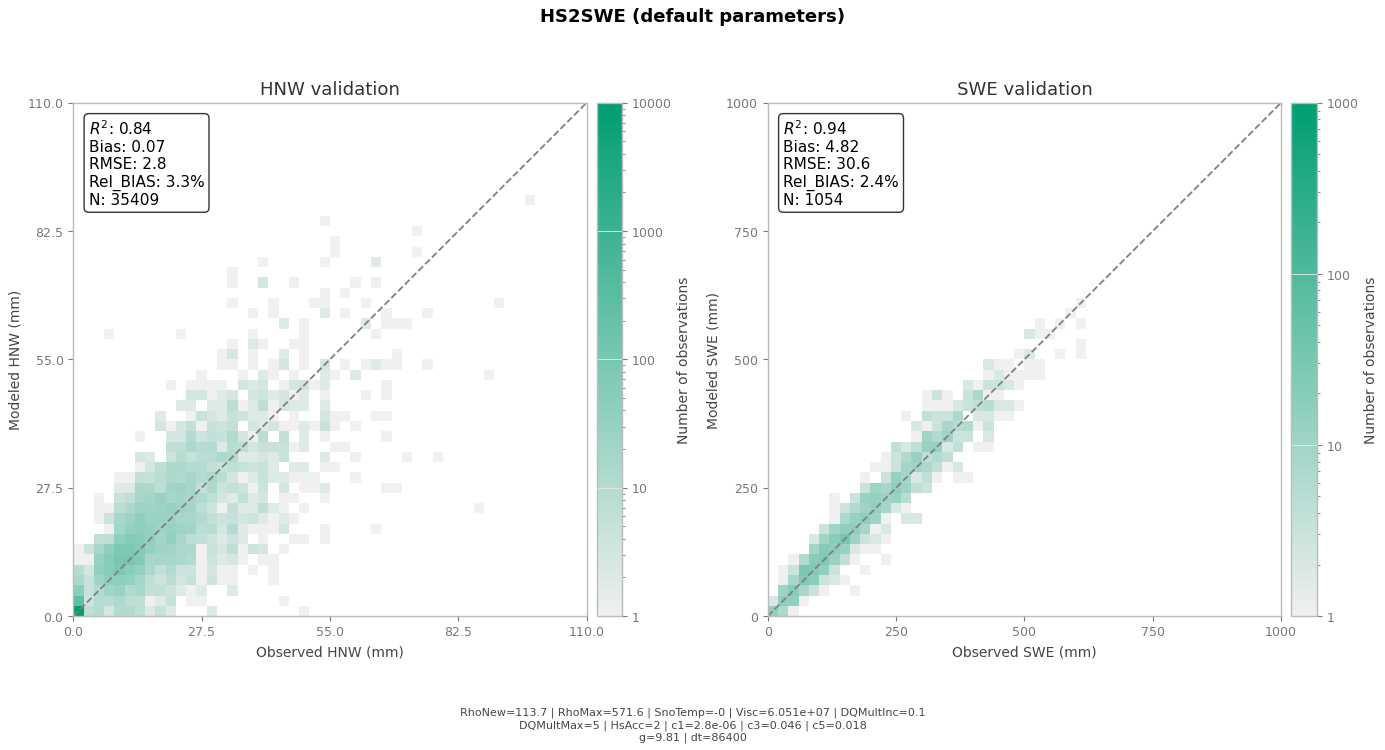


Results summary:
{'HNW': {'RMSE': np.float64(2.8408265771790893), 'Bias': np.float64(0.0677979544308451), 'Rel_BIAS': np.float64(0.03312622834885876), 'R2': np.float64(0.8424069520266753), 'N': 35409}, 'SWE': {'RMSE': np.float64(30.619310341366898), 'Bias': np.float64(4.819712642691097), 'Rel_BIAS': np.float64(0.0242515504610986), 'R2': np.float64(0.9368592074769758), 'N': 1054}}


In [24]:
# ── Combined HNW + SWE validation plot ───────────────────────────────────────
results = val_helper.validate_hnw_swe_combined(
    hnw_df     = HNW_val,
    swe_df     = SWE_val,
    model_name = f"HS2SWE ({calib_comment} parameters)",
    params     = params_display,
    full_season= False,
    save_dir   = save_dir if save_fig else None,
    filename   = f"HS2SWE_combined_validation_{calib_comment}.png",
    cmap       = cmap,
)

print("\nResults summary:")
print(results)